### Imports e iniciando cessão com o S3

In [ ]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [ ]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [ ]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)

📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [176]:
def listar_arquivos_s3(
    s3_client,
    bucket: str,
    prefixo: str = ""
) -> pd.DataFrame:

    paginator = s3_client.get_paginator("list_objects_v2")

    arquivos = []

    for pagina in paginator.paginate(
        Bucket=bucket,
        Prefix=prefixo
    ):
        for obj in pagina.get("Contents", []):

            arquivos.append({
                "CAMINHO": obj["Key"],
                "ARQUIVO": obj["Key"].split("/")[-1],
                "TAMANHO_MB": round(
                    obj["Size"] / 1024 / 1024, 2
                ),
                "DATA_MODIFICACAO": obj["LastModified"]
            })

    return (
        pd.DataFrame(arquivos)
        .sort_values(
            "DATA_MODIFICACAO",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [177]:
df_s3 = listar_arquivos_s3(
    s3_client=s3,
    bucket=BUCKET,
    prefixo="gold/"
)

df_s3

,CAMINHO,ARQUIVO,TAMANHO_MB,DATA_MODIFICACAO
0,gold/dados_externos/fact_uf_ano.parquet,fact_uf_ano.parquet,0.02,2026-09-08 02:12:06+00:00
1,gold/dados_externos/fact_escola.parquet,fact_escola.parquet,3.74,2026-09-08 02:11:29+00:00
2,gold/dados_externos/ranking_prioridade.parquet,ranking_prioridade.parquet,0.94,2026-09-07 20:45:24+00:00
3,gold/dados_externos/fact_municipio.parquet,fact_municipio.parquet,0.11,2026-09-07 20:45:24+00:00
4,gold/dados_externos/dim_contexto_socioeconomic...,dim_contexto_socioeconomico_uf.parquet,0.01,2026-09-07 20:45:22+00:00
5,gold/dados_externos/analise_uf.parquet,analise_uf.parquet,0.02,2026-09-07 20:45:21+00:00
6,gold/dados_externos/analise_municipio.parquet,analise_municipio.parquet,0.69,2026-09-07 20:45:20+00:00
7,gold/dados_externos/,,0.00,2026-08-29 13:54:23+00:00
8,gold/fato/ano=2026/dados/Fato_Alfabetizacao_Me...,Fato_Alfabetizacao_Meta.parquet,15.94,2026-08-15 14:53:09+00:00
9,gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.pa...,FATO_ALFABETIZACAO.parquet,8.54,2026-08-15 14:52:34+00:00


In [179]:

def carregar_parquet_s3(
    s3_client,
    bucket: str,
    nome_tabela: str,
    camada: str = "gold",
    ano: str | int = None,
    subpasta: str = None,
    ler_dicionario: bool = False,
) -> pd.DataFrame:
    """
    Carrega qualquer arquivo Parquet do S3 de forma flexível.
    
    Exemplos de chaves geradas:
    - Com ano:        'gold/ano=historico/dados/TS_ALUNO.parquet'
    - Dados externos: 'gold/dados_externos/fact_escola.parquet'
    - Fato 2026:      'gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet'
    """
    nome_arquivo = f"dicionario_{nome_tabela}.parquet" if ler_dicionario else f"{nome_tabela}.parquet"
    
    # Montagem dinâmica da chave no S3
    if subpasta:
        # Se você passar uma subpasta direta (ex: 'dados_externos' ou 'fato/ano=2026/dados')
        chave = f"{camada}/{subpasta}/{nome_arquivo}"
    elif ano is not None:
        # Padrão com partição de ano
        pasta_interna = "dicionario" if ler_dicionario else "dados"
        chave = f"{camada}/ano={ano}/{pasta_interna}/{nome_arquivo}"
    else:
        # Padrão direto na camada
        chave = f"{camada}/{nome_arquivo}"

    print(f"Lendo: s3://{bucket}/{chave}")

    try:
        obj = s3_client.get_object(Bucket=bucket, Key=chave)
        return pd.read_parquet(BytesIO(obj["Body"].read()))
    except s3_client.exceptions.NoSuchKey:
        raise FileNotFoundError(f"Arquivo não encontrado:\ns3://{bucket}/{chave}")
    except Exception as e:
        raise RuntimeError(f"Erro ao ler {chave} do bucket {bucket}.\n{e}")


In [43]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")


df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet


In [44]:
df_fact_uf_ano          = carregar_parquet_s3(s3, BUCKET, "fact_uf_ano", subpasta="dados_externos")
df_fact_municipio       = carregar_parquet_s3(s3, BUCKET, "fact_municipio", subpasta="dados_externos")
df_dim_contexto_socioeconomico_uf    = carregar_parquet_s3(s3, BUCKET, "dim_contexto_socioeconomico_uf", subpasta="dados_externos")
df_ranking_prioridade   = carregar_parquet_s3(s3, BUCKET, "ranking_prioridade", subpasta="dados_externos")
df_fact_escola          = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")
df_analise_uf           = carregar_parquet_s3(s3, BUCKET, "analise_uf", subpasta="dados_externos")
df_analise_municipio    = carregar_parquet_s3(s3, BUCKET, "analise_municipio", subpasta="dados_externos")
df_fact_escola          = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")

Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_uf_ano.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/ranking_prioridade.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/analise_uf.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/analise_municipio.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [ ]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [ ]:
# 1. Selecionamos as colunas do município
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

# Se houver ID_TIPO_REDE, filtramos pelo Total (geralmente 0) ou pegamos os dados
if 'ID_TIPO_REDE' in df_municipios.columns and (df_municipios['ID_TIPO_REDE'] == 0).any():
    df_muni_filtrado = df_municipios[df_municipios['ID_TIPO_REDE'] == 0][cols_muni].copy()
else:
    df_muni_filtrado = df_municipios[cols_muni].copy()

# 2. Renomeamos para os nomes finais desejados
df_muni_filtrado = df_muni_filtrado.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Fazemos o Merge
df_alunos = df_alunos.merge(
    df_muni_filtrado.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE'],
    how='left'
)

print("[SUCESSO] Dados de Município agregados!")
print("Colunas agora em df_alunos:", [c for c in df_alunos.columns if 'MUNICIPIO' in c])


[SUCESSO] Dados de Município agregados!
Colunas agora em df_alunos: ['CO_MUNICIPIO', 'NO_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO']


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [ ]:
# 1. Selecionamos as colunas do estado
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']
cols_uf_existentes = [c for c in cols_uf if c in df_estados.columns]

# Se houver ID_TIPO_REDE, filtramos pelo Total (geralmente 0)
if 'ID_TIPO_REDE' in df_estados.columns and (df_estados['ID_TIPO_REDE'] == 0).any():
    df_estados_filtrado = df_estados[df_estados['ID_TIPO_REDE'] == 0][cols_uf_existentes].copy()
else:
    df_estados_filtrado = df_estados[cols_uf_existentes].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_filtrado = df_estados_filtrado.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Fazemos o Merge se a coluna ainda não existir
if 'VL_MEDIA_LP_TOTAL_UF' not in df_alunos.columns:
    df_alunos = df_alunos.merge(
        df_estados_filtrado.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE'],
        how='left'
    )
    print("[SUCESSO] Dados de Estado agregados!")
else:
    print("[INFO] 'VL_MEDIA_LP_TOTAL_UF' já estava presente em df_alunos.")


[SUCESSO] Dados de Estado agregados!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [ ]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [ ]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 43


In [ ]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## <font color="blue">Detalhes</font>


In [ ]:
df_alunos.columns

Index(['NU_ANO_AVALIACAO', 'CO_UF', 'TP_DEPENDENCIA', 'CO_MUNICIPIO',
       'IN_PRESENCA_LP', 'IN_PREENCHIMENTO_LP', 'VL_PESO_ALUNO_LP',
       'VL_PROFICIENCIA_LP', 'IN_ALFABETIZADO', 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
       'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF',
       'PC_ALUNO_ALFABETIZADO_TOTAL_UF', 'META_MUN_2024', 'META_MUN_2025',
       'META_MUN_2026', 'META_UF_2024_x', 'META_UF_2025_x', 'META_UF_2026_x'],
      dtype='str')

In [ ]:
colunas = ['NU_ANO_AVALIACAO','CO_UF','TP_DEPENDENCIA','CO_MUNICIPIO','IN_PRESENCA_LP','IN_PREENCHIMENTO_LP','VL_PESO_ALUNO_LP','VL_PROFICIENCIA_LP','IN_ALFABETIZADO','VL_MEDIA_LP_TOTAL_MUNICIPIO','PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF','META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026', 'META_UF_2024_x','META_UF_2025_x', 'META_UF_2026_x']



In [ ]:
df_alunos = df_alunos[colunas]

In [ ]:
df_municipios.isna().sum()

NU_ANO_AVALIACAO             0
CO_UF                        0
SG_UF                        0
CO_MUNICIPIO                 0
NO_MUNICIPIO                 0
TP_SERIE                     0
ID_TIPO_REDE                 0
PC_ALUNO_ALFABETIZADO        0
VL_MEDIA_LP                  0
DESC_SERIE                   0
ANO                          0
PC_ALUNO_NIVEL_0_LP      11547
PC_ALUNO_NIVEL_1_LP      11547
PC_ALUNO_NIVEL_2_LP      11547
PC_ALUNO_NIVEL_3_LP      11547
PC_ALUNO_NIVEL_4_LP      11547
PC_ALUNO_NIVEL_5_LP      11547
PC_ALUNO_NIVEL_6_LP      11547
PC_ALUNO_NIVEL_7_LP      11547
PC_ALUNO_NIVEL_8_LP      11547
dtype: int64

In [ ]:
df_alunos.isna().sum()

NU_ANO_AVALIACAO                               0
CO_UF                                          0
TP_DEPENDENCIA                               628
CO_MUNICIPIO                                 628
IN_PRESENCA_LP                                 0
IN_PREENCHIMENTO_LP                            0
VL_PESO_ALUNO_LP                          769525
VL_PROFICIENCIA_LP                        769525
IN_ALFABETIZADO                                0
VL_MEDIA_LP_TOTAL_MUNICIPIO              5880074
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO    5880074
VL_MEDIA_LP_TOTAL_UF                     5878809
PC_ALUNO_ALFABETIZADO_TOTAL_UF           5878809
META_MUN_2024                             227169
META_MUN_2025                             193698
META_MUN_2026                             167126
META_UF_2024_x                            365352
META_UF_2025_x                            284256
META_UF_2026_x                            284256
dtype: int64

In [ ]:
df_alunos.shape[0] - 5880074

210717

In [ ]:
df_meta[['QT_ALUNOS','QT_ALFABETIZADOS']]

,QT_ALUNOS,QT_ALFABETIZADOS
0,16,0
1,16,0
2,16,0
3,16,0
4,16,0
...,...,...
11589065,269,159
11589066,269,159
11589067,269,159
11589068,269,159


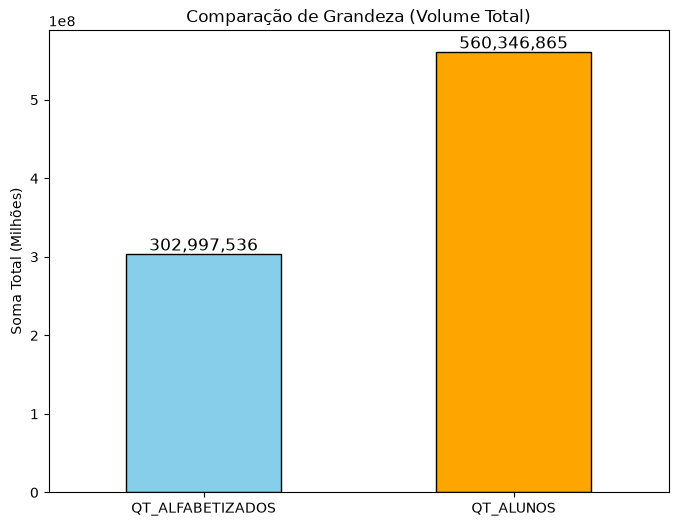

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

totais = df_meta[['QT_ALFABETIZADOS', 'QT_ALUNOS']].sum()
totais.plot.bar(color=['skyblue', 'orange'], edgecolor='black')

plt.title('Comparação de Grandeza (Volume Total)')
plt.ylabel('Soma Total (Milhões)')
plt.xticks(rotation=0) # Deixa o texto do eixo X deitado (horizontal)


for i, valor in enumerate(totais):
    plt.text(i, valor, f'{valor:,.0f}', ha='center', va='bottom', fontsize=12)

plt.show()


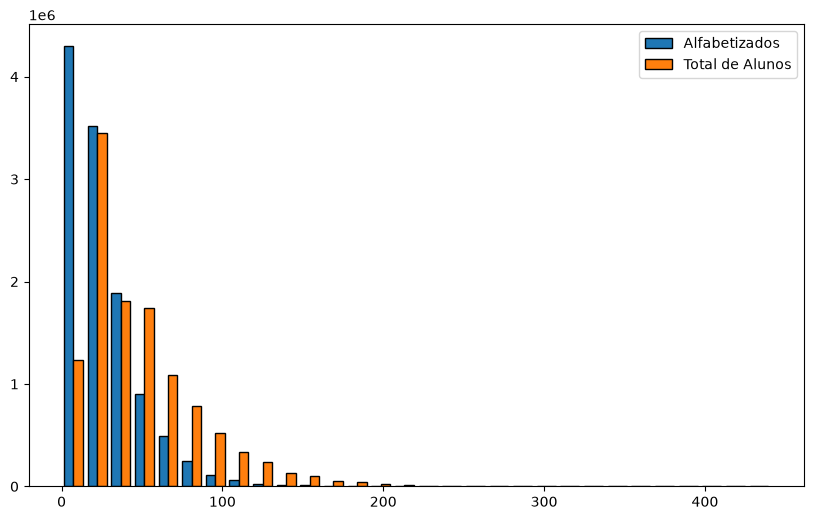

In [ ]:
# Alternativa puramente com Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(
    [df_meta['QT_ALFABETIZADOS'], df_meta['QT_ALUNOS']], 
    bins=30, 
    label=['Alfabetizados', 'Total de Alunos'],
    edgecolor='black'
)

plt.legend()
plt.show()


In [ ]:
tabelas = ['RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS_MUNICIPIO','RESULTADOS_METAS','TS_ALUNO','TS_ESTADO','TS_ITEM','TS_MUNICIPIO' ] 
pastas = ['dimensao','historico','fato'] 


df = carregar_parquet_s3(
    s3_client=s3,
    bucket=BUCKET,
    ano= pastas[0],
    nome_tabela=tabelas[0],
    camada="gold"
)


Lendo: s3://postech-challenge-datascience-003/gold/ano=dimensao/dados/RESULTADOS_METAS_MUNICIPIO.parquet


Target: Alunos alfabetizados

Quantidade de alunos alfabetizados

In [ ]:
df_alunos["IN_ALFABETIZADO"].value_counts(dropna=False)

IN_ALFABETIZADO
1    3287584
0    2803207
Name: count, dtype: Int64

Proporção de alunos alfabetizados vs não alfabetizados

In [ ]:
df_alunos["IN_ALFABETIZADO"].value_counts(normalize=True, dropna=False)

IN_ALFABETIZADO
1    0.539763
0    0.460237
Name: proportion, dtype: Float64

Quantidade de avaliaçoes por ano

In [ ]:
if "NU_ANO_AVALIACAO" not in df_alunos.columns and "ANO" in df_alunos.columns:
    df_alunos = df_alunos.rename(columns={"ANO": "NU_ANO_AVALIACAO"})

df_alunos["NU_ANO_AVALIACAO"].value_counts().sort_index()

NU_ANO_AVALIACAO
2023    1747439
2024    2120560
2025    2222792
Name: count, dtype: Int64

Evolução temporal
Proporção de alunos Alfabetizados por ano

In [ ]:
pd.crosstab(
    df_alunos["NU_ANO_AVALIACAO"],
    df_alunos["IN_ALFABETIZADO"],
    normalize="index"
) * 100

IN_ALFABETIZADO,0,1
NU_ANO_AVALIACAO,,
2023,49.787832,50.212168
2024,47.791197,52.208803
2025,41.378321,58.621679


Podemos notar que estamos evoluindo positivamente a quantidade de alunos alfabetizados ao longo do tempo. +8p.p. em 2 anos.


Primeira hipótese analítica:

H1 — A proporção de alunos alfabetizados apresenta evolução positiva ao longo do período analisado.

Essa evolução aconteceu de forma homogênea ou foi concentrada em determinados territórios?


In [ ]:
df_alunos.groupby("IN_ALFABETIZADO")["VL_PROFICIENCIA_LP"].describe()

,count,mean,std,min,25%,50%,75%,max
IN_ALFABETIZADO,,,,,,,,
0,2033682.0,701.931944,32.675350,572.355874,681.494367,709.411471,729.250713,742.999958
1,3287584.0,780.219544,26.392243,743.000000,759.870886,775.481946,795.056066,904.382031


Aluno
 ├── características educacionais
 ├── escola
 ├── município
 ├── estado
 └── contexto socioeconômico
              ↓
          ML
              ↓
 P(alfabetizado)

Resultado histórico
       +
Previsão dos alunos
       +
Meta
       ↓
Projeção 2030
       ↓
🟢 provável atingir
🟡 atenção
🔴 provável não atingir

VL_PROFICIENCIA_LP < 743
             ↓
   IN_ALFABETIZADO = 0

VL_PROFICIENCIA_LP >= 743
             ↓
   IN_ALFABETIZADO = 1

as métricas calculadas como 
PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO
VL_MEDIA_LP_TOTAL_MUNICIPIO
PC_ALUNO_ALFABETIZADO_TOTAL_UF
VL_MEDIA_LP_TOTAL_UF 
não entram no modelo, porque seriam Data Leakeage, já que foram calculadas a partir dos resultados das avaliaçoes



In [ ]:
df_alunos.groupby("SG_UF").agg(
    alunos=("ID_ALUNO", "count"),
    alfabetizados=("IN_ALFABETIZADO", "sum"),
    taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
).sort_values(
    "taxa_alfabetizacao",
    ascending=False
)

KeyError: 'SG_UF'

In [ ]:
df_alunos.groupby(
    ["NU_ANO_AVALIACAO", "SG_UF"]
).agg(
    alunos=("ID_ALUNO", "count"),
    taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
).reset_index()

KeyError: 'SG_UF'

In [37]:
df_uf_ano = (
    df_alunos
    .groupby(["NU_ANO_AVALIACAO", "SG_UF"])
    .agg(
        alunos=("ID_ALUNO", "count"),
        taxa_alfabetizacao=("IN_ALFABETIZADO", "mean")
    )
    .reset_index()
)

# transformar de proporção para percentual
df_uf_ano["taxa_alfabetizacao"] *= 100

df_uf_ano.head()

,NU_ANO_AVALIACAO,SG_UF,alunos,taxa_alfabetizacao
0,2023,AL,35503,41.078219
1,2023,AM,63055,40.57093
2,2023,AP,12349,37.32286
3,2023,BA,137724,31.574744
4,2023,CE,100349,80.660495


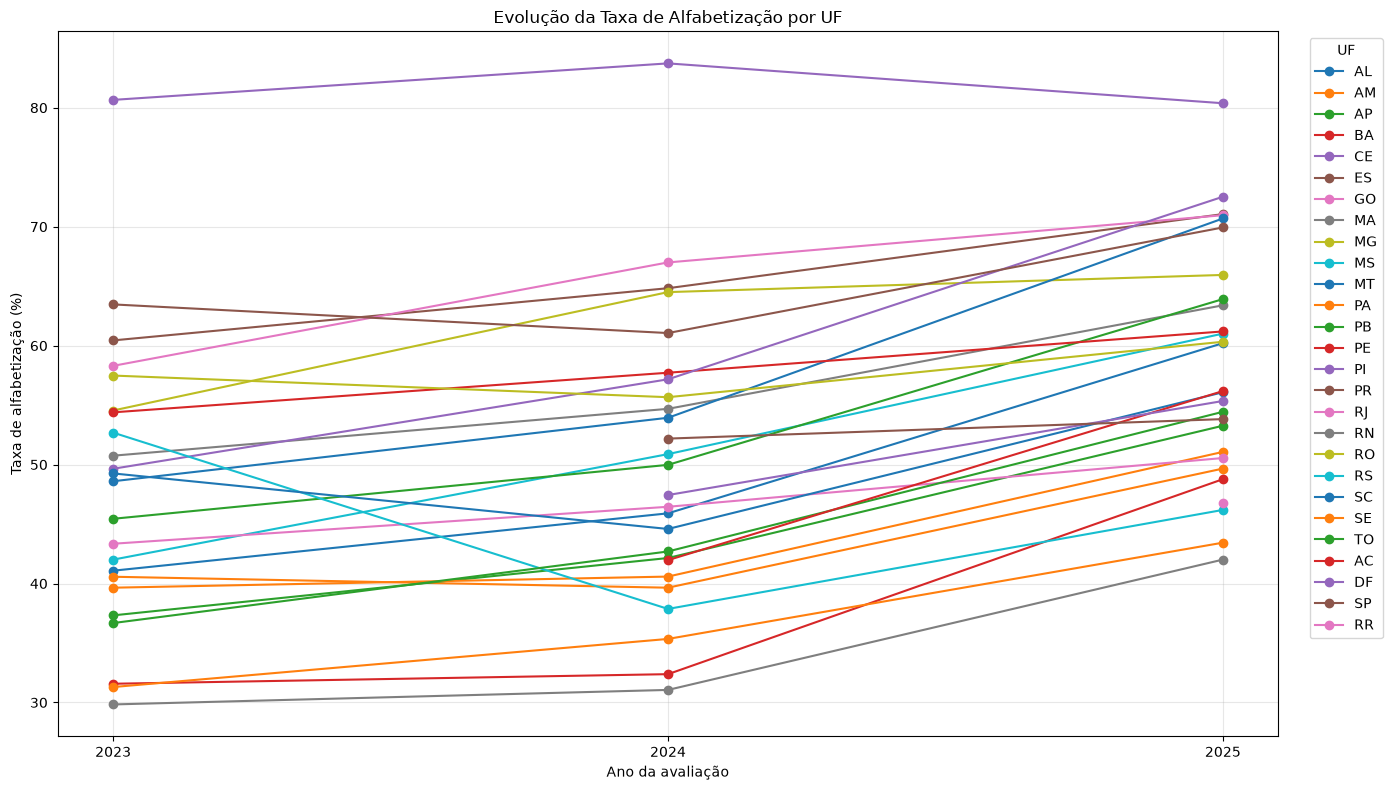

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for uf in df_uf_ano["SG_UF"].unique():
    dados_uf = df_uf_ano[df_uf_ano["SG_UF"] == uf]
    
    plt.plot(
        dados_uf["NU_ANO_AVALIACAO"],
        dados_uf["taxa_alfabetizacao"],
        marker="o",
        label=uf
    )

plt.title("Evolução da Taxa de Alfabetização por UF")
plt.xlabel("Ano da avaliação")
plt.ylabel("Taxa de alfabetização (%)")
plt.xticks(sorted(df_uf_ano["NU_ANO_AVALIACAO"].unique()))
plt.legend(
    title="UF",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

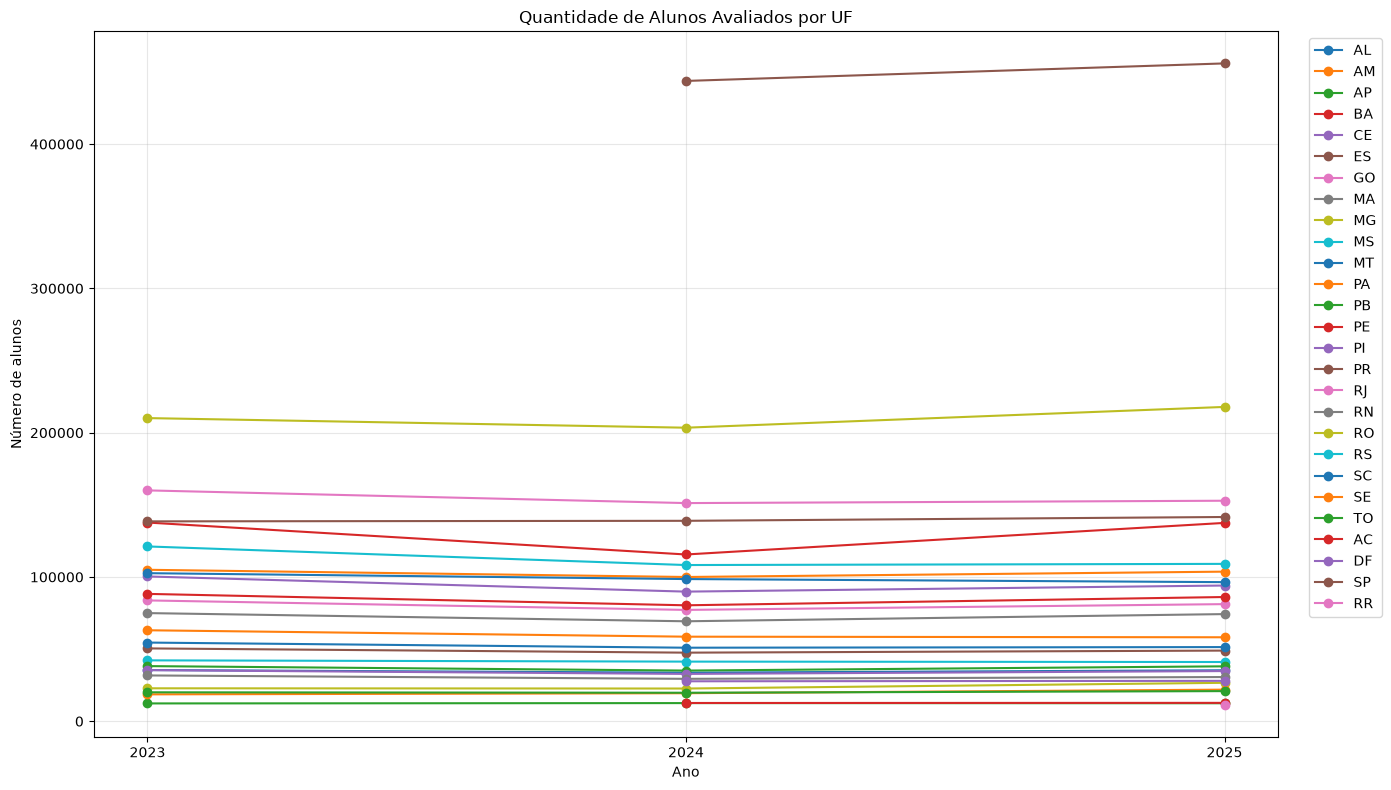

In [39]:
plt.figure(figsize=(14, 8))

for uf in df_uf_ano["SG_UF"].unique():
    dados = df_uf_ano[df_uf_ano["SG_UF"] == uf]
    
    plt.plot(
        dados["NU_ANO_AVALIACAO"],
        dados["alunos"],
        marker="o",
        label=uf
    )

plt.title("Quantidade de Alunos Avaliados por UF")
plt.xlabel("Ano")
plt.ylabel("Número de alunos")
plt.xticks([2023, 2024, 2025])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
df_heatmap = df_uf_ano.pivot(
    index="SG_UF",
    columns="NU_ANO_AVALIACAO",
    values="taxa_alfabetizacao"
)

df_heatmap

NU_ANO_AVALIACAO,2023,2024,2025
SG_UF,,,
AC,<NA>,41.967602,56.180834
AL,41.078219,45.901152,60.207172
AM,40.57093,39.649877,49.663207
AP,37.32286,42.146264,53.266453
BA,31.574744,32.380425,48.770978
CE,80.660495,83.729032,80.37867
DF,<NA>,47.440248,55.346047
ES,60.439365,64.828137,71.05892
GO,58.299996,66.995827,70.966431


## <font color="blue">Novos fatos</font>

In [216]:
bases = {
    "df_fact_escola": df_fact_escola,
    "df_fact_municipio": df_fact_municipio,
    "df_fact_uf_ano": df_fact_uf_ano,
    "df_dim_contexto_socioeconomico_uf": df_dim_contexto_socioeconomico_uf,
    "df_fato_alfabetizacao": df_alfabetizacao,
    "df_fato_alfabetizacao_meta": df_meta,
    "df_ranking_prioridade": df_ranking_prioridade,
    "df_analise_uf": df_analise_uf,
    "df_analise_municipio": df_analise_municipio
}

### Verificaçoes 

In [ ]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print("Dimensão:", df.shape)
    print("Colunas:", df.columns.tolist())
    print()

df_fact_escola
Dimensão: (517080, 15)
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'CO_ENTIDADE', 'FUN_02_CAT_0', 'COD_RISCO_ESCOLA', 'CATEGORIA_RISCO_ESCOLA', 'NIVEL_RISCO_DESC_ESCOLA', 'DESC_IMPACTO_ESCOLA', 'QT_MATRICULA_2ANO_EF', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']

df_fact_municipio
Dimensão: (16711, 14)
Colunas: ['ANO', 'COD_UF', 'CO_MUNICIPIO', 'FUN_02_CAT_0', 'COD_RISCO_UF', 'CATEGORIA_RISCO_UF', 'COD_RISCO_MUNICIPIO', 'CATEGORIA_RISCO_MUNICIPIO', 'NIVEL_RISCO_DESC_MUNICIPIO', 'UF_POPULACAO_MIL', 'UF_TAXA_ANALFABETISMO_PCT', 'UF_RENDIMENTO_MEDIO_MENSAL_REAIS', 'UF_RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT']

df_fact_uf_ano
Dimensão: (81, 32)
Colunas: ['ANO', 'COD_REGIAO', 'NO_REGIAO', 'COD_UF', 'SG_UF', 'UNIDGEO', 'ED_INF_CAT_0', 'CRE_CAT_0', 'PRE_CAT_0', 'FUN_CAT_0', 'FUN_AI_CAT_0', 'FUN_AF_CAT_0', 'FUN_01_CAT_0', 'FUN_02_CAT_0', 'FUN_03_CAT_0'

In [218]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print(df.dtypes)
    print()

df_fact_escola
ANO                                 float64
COD_UF                                int64
CO_MUNICIPIO                        float64
CO_ENTIDADE                         float64
FUN_02_CAT_0                        float64
COD_RISCO_ESCOLA                    float64
CATEGORIA_RISCO_ESCOLA                  str
NIVEL_RISCO_DESC_ESCOLA                 str
DESC_IMPACTO_ESCOLA                     str
QT_MATRICULA_2ANO_EF                float64
UF_POPULACAO_MIL                      int64
UF_TAXA_ANALFABETISMO_PCT           float64
UF_RENDIMENTO_MEDIO_MENSAL_REAIS      int64
UF_RENDA_PERCAPITA_SBENEF_MEDIO     float64
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       float64
dtype: object

df_fact_municipio
ANO                                 float64
COD_UF                                int64
CO_MUNICIPIO                        float64
FUN_02_CAT_0                        float64
COD_RISCO_UF                        float64
CATEGORIA_RISCO_UF                      str
COD_RISCO_MUNICIPIO         

In [219]:
for nome, df in bases.items():
    print("=" * 80)
    print(nome)
    print("\nNulos:")
    display(
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

print("\nDuplicados:")
print(df.duplicated().sum())

df_fact_escola

Nulos:


QT_MATRICULA_2ANO_EF                387289
COD_RISCO_ESCOLA                    387277
CATEGORIA_RISCO_ESCOLA              387277
NIVEL_RISCO_DESC_ESCOLA             387277
DESC_IMPACTO_ESCOLA                 387277
FUN_02_CAT_0                        235695
ANO                                      0
COD_UF                                   0
CO_MUNICIPIO                             0
CO_ENTIDADE                              0
UF_POPULACAO_MIL                         0
UF_TAXA_ANALFABETISMO_PCT                0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS         0
UF_RENDA_PERCAPITA_SBENEF_MEDIO          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT            0
dtype: int64

df_fact_municipio

Nulos:


COD_RISCO_MUNICIPIO                 312
CATEGORIA_RISCO_MUNICIPIO           312
NIVEL_RISCO_DESC_MUNICIPIO          312
COD_RISCO_UF                         72
CATEGORIA_RISCO_UF                   72
FUN_02_CAT_0                          2
ANO                                   0
COD_UF                                0
CO_MUNICIPIO                          0
UF_POPULACAO_MIL                      0
UF_TAXA_ANALFABETISMO_PCT             0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS      0
UF_RENDA_PERCAPITA_SBENEF_MEDIO       0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT         0
dtype: int64

df_fact_uf_ano

Nulos:


...

df_analise_uf

Nulos:


GAP_META_UF                         27
META_UF_REFERENCIA                  27
META_UF_FINAL_2024                   6
META_UF_FINAL_2025                   3
META_UF_FINAL_2026                   3
META_UF_FINAL_2027                   3
META_UF_FINAL_2028                   3
META_UF_FINAL_2029                   3
NU_ANO_AVALIACAO                     0
UF_POPULACAO_MIL                     0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT        0
UF_RENDA_PERCAPITA_SBENEF_MEDIO      0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS     0
UF_TAXA_ANALFABETISMO_PCT            0
META_UF_FINAL_2030                   0
CATEGORIA_RISCO_UF                   0
COD_RISCO_UF                         0
CO_UF                                0
ALFABETIZACAO_UF                     0
MEDIA_LP_UF                          0
TP_SERIE                             0
ATINGIU_META_UF                      0
dtype: int64

df_analise_municipio

Nulos:


DIF_META_MUNICIPIO                  5370
META_MUNICIPIO_REFERENCIA           5370
META_MUNICIPIO_FINAL_2024            558
META_MUNICIPIO_FINAL_2025            438
META_MUNICIPIO_FINAL_2028            392
META_MUNICIPIO_FINAL_2026            392
META_MUNICIPIO_FINAL_2027            392
META_MUNICIPIO_FINAL_2029            392
META_MUNICIPIO_FINAL_2030            392
NIVEL_RISCO_DESC_MUNICIPIO           263
CATEGORIA_RISCO_MUNICIPIO            263
COD_RISCO_MUNICIPIO                  263
CATEGORIA_RISCO_UF                    43
COD_RISCO_UF                          43
FUN_02_CAT_0                           2
UF_RENDA_PERCAPITA_SBENEF_MEDIO        0
UF_TAXA_ANALFABETISMO_PCT              0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT          0
ATINGIU_META_MUNICIPIO                 0
UF_RENDIMENTO_MEDIO_MENSAL_REAIS       0
NU_ANO_AVALIACAO                       0
UF_POPULACAO_MIL                       0
CO_UF                                  0
ALFABETIZACAO_MUNICIPIO                0
MEDIA_LP_MUNICIP


Duplicados:
0


### 1. Tratativa de duplicidades - erro de cidade=estado

#### df_fact_uf_ano
tratativa duplicidade estado e municipio rj e sp 

In [97]:
sorted(df_fact_uf_ano["ANO"].unique())

[np.int64(2023), np.int64(2024), np.int64(2025)]

In [118]:
df_fact_uf_ano.groupby("ANO").size()

ANO
2023    27
2024    27
2025    27
dtype: int64

In [119]:
for ano in sorted(df_fact_uf_ano["ANO"].unique()):
    
    print(f"\n{'='*50}")
    print(f"ANO: {ano}")
    
    display(
        df_fact_uf_ano[
            df_fact_uf_ano["ANO"] == ano
        ][["ANO", "COD_UF", "SG_UF", "NO_REGIAO", "UNIDGEO"]]
        .sort_values("COD_UF")
    )


ANO: 2023


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
0,2023,11.0,RO,Norte,Rondônia
1,2023,12.0,AC,Norte,Acre
2,2023,13.0,AM,Norte,Amazonas
3,2023,14.0,RR,Norte,Roraima
4,2023,15.0,PA,Norte,Pará
5,2023,16.0,AP,Norte,Amapá
6,2023,17.0,TO,Norte,Tocantins
7,2023,21.0,MA,Nordeste,Maranhão
8,2023,22.0,PI,Nordeste,Piauí
9,2023,23.0,CE,Nordeste,Ceará



ANO: 2024


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
27,2024,11.0,RO,Norte,Rondônia
28,2024,12.0,AC,Norte,Acre
29,2024,13.0,AM,Norte,Amazonas
30,2024,14.0,RR,Norte,Roraima
31,2024,15.0,PA,Norte,Pará
32,2024,16.0,AP,Norte,Amapá
33,2024,17.0,TO,Norte,Tocantins
34,2024,21.0,MA,Nordeste,Maranhão
35,2024,22.0,PI,Nordeste,Piauí
36,2024,23.0,CE,Nordeste,Ceará



ANO: 2025


,ANO,COD_UF,SG_UF,NO_REGIAO,UNIDGEO
54,2025,11.0,RO,Norte,Rondônia
55,2025,12.0,AC,Norte,Acre
56,2025,13.0,AM,Norte,Amazonas
57,2025,14.0,RR,Norte,Roraima
58,2025,15.0,PA,Norte,Pará
59,2025,16.0,AP,Norte,Amapá
60,2025,17.0,TO,Norte,Tocantins
61,2025,21.0,MA,Nordeste,Maranhão
62,2025,22.0,PI,Nordeste,Piauí
63,2025,23.0,CE,Nordeste,Ceará


In [120]:
df_fact_uf_ano[
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 33)
].T

,18
ANO,2023
COD_REGIAO,3.0
NO_REGIAO,Sudeste
COD_UF,33.0
SG_UF,RJ
UNIDGEO,Rio de Janeiro
ED_INF_CAT_0,5.7
CRE_CAT_0,6.9
PRE_CAT_0,4.9
FUN_CAT_0,5.0


In [116]:
df_fact_uf_ano[
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 35)
].T

,19
ANO,2023
COD_REGIAO,3.0
NO_REGIAO,Sudeste
COD_UF,35.0
SG_UF,SP
UNIDGEO,São Paulo
ED_INF_CAT_0,7.3
CRE_CAT_0,8.9
PRE_CAT_0,5.6
FUN_CAT_0,5.6


In [117]:
df_fact_uf_ano[
    df_fact_uf_ano.duplicated(
        subset=["ANO", "COD_UF"],
        keep=False
    )
].sort_values(["ANO", "COD_UF"])

,ANO,COD_REGIAO,NO_REGIAO,COD_UF,SG_UF,UNIDGEO,ED_INF_CAT_0,CRE_CAT_0,PRE_CAT_0,FUN_CAT_0,...,MED_01_CAT_0,MED_02_CAT_0,MED_03_CAT_0,MED_04_CAT_0,MED_NS_CAT_0,POPULACAO_MIL,TAXA_ANALFABETISMO_PCT,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,TAXA_FREQ_LIQUIDA_FUND_PCT


#### df_fact_escola
tratativa duplicidade estado e municipio rj e sp 
correçao das duplicidades do val;or da cidade de sp e rj que subiu como estado, duplicando o valor.

In [114]:
condicao = (
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 33) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_uf_ano["ANO"] == 2023) &
    (df_fact_uf_ano["COD_UF"] == 35) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_uf_ano["ANO"] == 2024) &
    (df_fact_uf_ano["COD_UF"] == 33) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_uf_ano["ANO"] == 2024) &
    (df_fact_uf_ano["COD_UF"] == 35) &
    (df_fact_uf_ano["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_uf_ano = df_fact_uf_ano[~condicao].reset_index(drop=True)

In [153]:
cols_uf = [
    "UF_POPULACAO_MIL",
    "UF_TAXA_ANALFABETISMO_PCT",
    "UF_RENDIMENTO_MEDIO_MENSAL_REAIS",
    "UF_RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT"
]

teste = (
    df_fact_escola
    .groupby(["ANO", "COD_UF"])[cols_uf]
    .nunique()
)

teste.max()

UF_POPULACAO_MIL                    1
UF_TAXA_ANALFABETISMO_PCT           1
UF_RENDIMENTO_MEDIO_MENSAL_REAIS    1
UF_RENDA_PERCAPITA_SBENEF_MEDIO     1
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       1
dtype: int64

In [154]:
teste[teste["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 1]

,,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
ANO,COD_UF,,,,,


In [155]:
teste[teste["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 1]

,,UF_POPULACAO_MIL,UF_TAXA_ANALFABETISMO_PCT,UF_RENDIMENTO_MEDIO_MENSAL_REAIS,UF_RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT
ANO,COD_UF,,,,,


In [156]:
df_fact_escola[
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35)
].T

,108958,108959,108960,108961,108962,108963,108964,108965,108966,108967,...,137884,137885,137886,137887,137888,137889,137890,137891,137892,137893
ANO,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,...,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0
COD_UF,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
CO_MUNICIPIO,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,3500105.0,...,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0,3557303.0
CO_ENTIDADE,35030806.0,35031045.0,35031082.0,35031100.0,35031112.0,35063113.0,35065262.0,35079911.0,35079923.0,35092319.0,...,35006278.0,35009732.0,35020382.0,35222318.0,35222392.0,35233596.0,35277241.0,35387859.0,35564709.0,35580788.0
FUN_02_CAT_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.3,5.1,NaN,...,9.0,NaN,NaN,9.0,NaN,NaN,NaN,9.0,NaN,NaN
COD_RISCO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,NaN,...,3.0,NaN,NaN,1.0,NaN,NaN,NaN,2.0,NaN,NaN
CATEGORIA_RISCO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderado,Baixo,NaN,...,Moderado,NaN,NaN,Muito baixo,NaN,NaN,NaN,Baixo,NaN,NaN
NIVEL_RISCO_DESC_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3 – Risco moderado de não alcançar a meta,2 – Risco moderado-baixo de não alcançar a meta,NaN,...,3 – Risco moderado de não alcançar a meta,NaN,NaN,1 – Baixo risco de não alcançar a meta,NaN,NaN,NaN,2 – Risco moderado-baixo de não alcançar a meta,NaN,NaN
DESC_IMPACTO_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Impacto em um grupo médio de estudantes,Impacto em um grupo reduzido de estudantes,NaN,...,Impacto em um grupo médio de estudantes,NaN,NaN,Poucos estudantes impactados,NaN,NaN,NaN,Impacto em um grupo reduzido de estudantes,NaN,NaN
QT_MATRICULA_2ANO_EF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0,74.0,NaN,...,20.0,NaN,NaN,63.0,NaN,NaN,NaN,57.0,NaN,NaN


In [149]:
condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

In [ ]:
condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2023) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 33) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_escola["ANO"] == 2024) &
    (df_fact_escola["COD_UF"] == 35) &
    (df_fact_escola["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_fact_escola = df_fact_escola[~condicao].reset_index(drop=True)

In [163]:
import io

caminho_s3 = "gold/dados_externos/fact_uf_ano.parquet"

buffer = io.BytesIO()

df_fact_uf_ano.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/fact_uf_ano.parquet


#### df_fact_municipio
tratativa duplicidade estado e municipio rj e sp 

In [182]:
condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)
condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

In [183]:
condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2023) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 33) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

condicao = (
    (df_fact_municipio["ANO"] == 2024) &
    (df_fact_municipio["COD_UF"] == 35) &
    (df_fact_municipio["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_fact_municipio = df_fact_municipio[~condicao].reset_index(drop=True)

In [184]:
chave = ["ANO", "COD_UF", "CO_MUNICIPIO"]

duplicados = (
    df_fact_municipio
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,ANO,COD_UF,CO_MUNICIPIO,qtd_registros


In [185]:
import io

caminho_s3 = "gold/dados_externos/fact_municipio.parquet"

buffer = io.BytesIO()

df_fact_municipio.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet


#### dim_contexto_socioeconomico_uf
tratativa duplicidade estado e municipio rj e sp 

In [192]:
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

In [193]:
condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2023) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 33) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

condicao = (
    (df_dim_contexto_socioeconomico_uf["ANO"] == 2024) &
    (df_dim_contexto_socioeconomico_uf["COD_UF"] == 35) &
    (df_dim_contexto_socioeconomico_uf["TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_dim_contexto_socioeconomico_uf = df_dim_contexto_socioeconomico_uf[~condicao].reset_index(drop=True)

In [194]:
chave = ["ANO", "COD_UF"]

duplicados = (
    df_dim_contexto_socioeconomico_uf
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,ANO,COD_UF,qtd_registros


In [195]:

caminho_s3 = "gold/dados_externos/dim_contexto_socioeconomico_uf.parquet"

buffer = io.BytesIO()

df_dim_contexto_socioeconomico_uf.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/dim_contexto_socioeconomico_uf.parquet


#### ranking_prioridade
tratativa duplicidade estado e municipio rj e sp 

In [205]:
chave = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]

duplicados = (
    df_ranking_prioridade
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,qtd_registros


In [198]:
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3477.73676)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3357.80555)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3379.23636)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_RENDA_PERCAPITA_SBENEF_MEDIO"] > 3455.07587)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

In [199]:
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 89.14750)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2023) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.4743)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 33) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 91.31985)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)
condicao = (
    (df_ranking_prioridade["NU_ANO_AVALIACAO"] == 2024) &
    (df_ranking_prioridade["CO_UF"] == 35) &
    (df_ranking_prioridade["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] > 92.0172)
)

df_ranking_prioridade = df_ranking_prioridade[~condicao].reset_index(drop=True)

In [200]:

caminho_s3 = "gold/dados_externos/ranking_prioridade.parquet"

buffer = io.BytesIO()

df_ranking_prioridade.to_parquet(
    buffer,
    index=False,
    engine="pyarrow"
)

buffer.seek(0)

s3.put_object(
    Bucket=BUCKET,
    Key=caminho_s3,
    Body=buffer.getvalue()
)

print(f"[SUCESSO] Arquivo salvo em s3://{BUCKET}/{caminho_s3}")

[SUCESSO] Arquivo salvo em s3://postech-challenge-datascience-003/gold/dados_externos/ranking_prioridade.parquet


#### analise_uf
tratativa duplicidade estado e municipio rj e sp 

In [215]:
teste_freq = (
    df_analise_uf
    .groupby(["NU_ANO_AVALIACAO", "CO_UF"])["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"]
    .nunique()
    .reset_index(name="qtd_valores")
)

teste_freq[teste_freq["qtd_valores"] > 1]

,NU_ANO_AVALIACAO,CO_UF,qtd_valores


#### analise_municipio
tratativa duplicidade estado e municipio rj e sp 

In [212]:
chave = ["NU_ANO_AVALIACAO", "CO_UF", "CO_MUNICIPIO"]

duplicados = (
    df_analise_municipio
    .groupby(chave)
    .size()
    .reset_index(name="qtd_registros")
    .query("qtd_registros > 1")
)

print(f"Combinações duplicadas: {len(duplicados)}")

display(duplicados)

Combinações duplicadas: 0


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,qtd_registros


### 2. Nulos

In [224]:
for nome, df in bases.items():

    print("=" * 80)
    print(nome)

    print("\nNulos:")

    nulos = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame("qtd_nulos")
    )

    nulos["pct_nulos"] = (
        nulos["qtd_nulos"] / len(df) * 100
    )

    display(nulos)



df_fact_escola

Nulos:


,qtd_nulos,pct_nulos
QT_MATRICULA_2ANO_EF,387289,74.899242
COD_RISCO_ESCOLA,387277,74.896921
CATEGORIA_RISCO_ESCOLA,387277,74.896921
NIVEL_RISCO_DESC_ESCOLA,387277,74.896921
DESC_IMPACTO_ESCOLA,387277,74.896921
FUN_02_CAT_0,235695,45.581922
ANO,0,0.000000
COD_UF,0,0.000000
CO_MUNICIPIO,0,0.000000
CO_ENTIDADE,0,0.000000


df_fact_municipio

Nulos:


,qtd_nulos,pct_nulos
COD_RISCO_MUNICIPIO,312,1.867034
CATEGORIA_RISCO_MUNICIPIO,312,1.867034
NIVEL_RISCO_DESC_MUNICIPIO,312,1.867034
COD_RISCO_UF,72,0.430854
CATEGORIA_RISCO_UF,72,0.430854
FUN_02_CAT_0,2,0.011968
ANO,0,0.000000
COD_UF,0,0.000000
CO_MUNICIPIO,0,0.000000
UF_POPULACAO_MIL,0,0.000000


df_fact_uf_ano

Nulos:


...

,qtd_nulos,pct_nulos
DIF_META_MUNICIPIO,5370,33.522692
META_MUNICIPIO_REFERENCIA,5370,33.522692
META_MUNICIPIO_FINAL_2024,558,3.483364
META_MUNICIPIO_FINAL_2025,438,2.734253
META_MUNICIPIO_FINAL_2027,392,2.447094
META_MUNICIPIO_FINAL_2028,392,2.447094
META_MUNICIPIO_FINAL_2030,392,2.447094
META_MUNICIPIO_FINAL_2029,392,2.447094
META_MUNICIPIO_FINAL_2026,392,2.447094
CATEGORIA_RISCO_MUNICIPIO,263,1.641800


df_analise_uf

Nulos:


,qtd_nulos,pct_nulos
GAP_META_UF,27,35.526316
META_UF_REFERENCIA,27,35.526316
META_UF_FINAL_2024,6,7.894737
META_UF_FINAL_2025,3,3.947368
META_UF_FINAL_2026,3,3.947368
META_UF_FINAL_2027,3,3.947368
META_UF_FINAL_2028,3,3.947368
META_UF_FINAL_2029,3,3.947368
NU_ANO_AVALIACAO,0,0.000000
UF_POPULACAO_MIL,0,0.000000


df_analise_municipio

Nulos:


,qtd_nulos,pct_nulos
DIF_META_MUNICIPIO,5370,33.522692
META_MUNICIPIO_REFERENCIA,5370,33.522692
META_MUNICIPIO_FINAL_2024,558,3.483364
META_MUNICIPIO_FINAL_2025,438,2.734253
META_MUNICIPIO_FINAL_2028,392,2.447094
META_MUNICIPIO_FINAL_2026,392,2.447094
META_MUNICIPIO_FINAL_2027,392,2.447094
META_MUNICIPIO_FINAL_2029,392,2.447094
META_MUNICIPIO_FINAL_2030,392,2.447094
NIVEL_RISCO_DESC_MUNICIPIO,263,1.641800


In [228]:
#display(df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"])
df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"] = df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"].astype(str)



In [229]:
display(df_fact_uf_ano["TAXA_FREQ_LIQUIDA_FUND_PCT"])

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
76    NaN
77    NaN
78    NaN
79    NaN
80    NaN
Name: TAXA_FREQ_LIQUIDA_FUND_PCT, Length: 81, dtype: str